# PCA y distancias geograficas/geneticas

Esta libreta evalua de forma exploratoria si los individuos de *Callisaurus draconoides* que estan mas separados geograficamente tambien presentan mayor distancia genetica. El analisis se hace por separado para los marcadores `cytb` y `mc1r`.

Se usan coordenadas directas entre puntos (haversine), sin modelar terreno, barreras geograficas ni conectividad ambiental. Por tiempo y por disponibilidad de datos, el objetivo es producir una lectura estadistica clara para la presentacion, no una conclusion biologica definitiva.

## Metodologia

1. Se leen las secuencias FASTA crudas y el catalogo de coordenadas limpio.
2. Se excluye `Holbrookia`, porque no tiene coordenadas asociadas y funciona como registro externo al conjunto principal.
3. Para el PCA, cada secuencia se transforma a one-hot encoding por posicion nucleotidica.
4. Para la comparacion de distancias, se calcula distancia genetica Hamming normalizada y distancia geografica haversine en kilometros.
5. Se ajusta una regresion lineal por marcador: `distancia_genetica ~ distancia_geografica_km / 100`.
6. Se complementa con una prueba tipo Mantel por permutacion para considerar que las distancias por pares no son observaciones independientes.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
import statsmodels.api as sm

sns.set_theme(style="whitegrid", context="notebook")

DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
RESULTS_DIR = Path("../results/marcel")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

COORDS_PATH = DATA_PROCESSED / "accessions_coordinates.csv"
FASTA_PATHS = {
    "cytb": DATA_RAW / "cytb.txt",
    "mc1r": DATA_RAW / "mc1r.txt",
}
GENE_BY_MARKER = {
    "cytb": "cytochrome b",
    "mc1r": "melanocortin 1 receptor",
}
BASES = np.array(list("ACGT"))
RANDOM_SEED = 42

assert COORDS_PATH.is_file(), f"No existe {COORDS_PATH}"
for marker, path in FASTA_PATHS.items():
    assert path.is_file(), f"No existe {path}"

In [2]:
def read_fasta(path: Path) -> pd.DataFrame:
    records = []
    current_id = None
    chunks = []

    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if current_id is not None:
                records.append({"id": current_id, "sequence": "".join(chunks)})
            current_id = line[1:].split()[0]
            chunks = []
        else:
            chunks.append(line.upper())

    if current_id is not None:
        records.append({"id": current_id, "sequence": "".join(chunks)})

    return pd.DataFrame(records)


def sequence_array(sequences: pd.Series) -> np.ndarray:
    lengths = sequences.str.len()
    assert lengths.nunique() == 1, f"Las secuencias tienen longitudes distintas: {lengths.value_counts().to_dict()}"
    arr = np.array([list(seq) for seq in sequences])
    invalid = set(arr.ravel()) - set(BASES)
    assert not invalid, f"Bases no esperadas: {invalid}"
    return arr


def one_hot_sequences(sequences: pd.Series) -> np.ndarray:
    arr = sequence_array(sequences)
    return np.concatenate([(arr == base).astype(float) for base in BASES], axis=1)


def hamming_distance_matrix(sequences: pd.Series) -> np.ndarray:
    arr = sequence_array(sequences)
    return (arr[:, None, :] != arr[None, :, :]).mean(axis=2)


def haversine_matrix(latitudes, longitudes) -> np.ndarray:
    lat = np.radians(np.asarray(latitudes, dtype=float))
    lon = np.radians(np.asarray(longitudes, dtype=float))
    dlat = lat[:, None] - lat[None, :]
    dlon = lon[:, None] - lon[None, :]
    a = np.sin(dlat / 2) ** 2 + np.cos(lat[:, None]) * np.cos(lat[None, :]) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    return 6371.0 * c


def upper_triangle_values(matrix: np.ndarray) -> np.ndarray:
    idx = np.triu_indices_from(matrix, k=1)
    return matrix[idx]


def mantel_test(distance_a: np.ndarray, distance_b: np.ndarray, permutations: int = 999, seed: int = RANDOM_SEED):
    rng = np.random.default_rng(seed)
    idx = np.triu_indices_from(distance_a, k=1)
    observed_a = distance_a[idx]
    observed_b = distance_b[idx]
    observed_r = np.corrcoef(observed_a, observed_b)[0, 1]

    count = 0
    for _ in range(permutations):
        perm = rng.permutation(distance_b.shape[0])
        permuted_b = distance_b[np.ix_(perm, perm)][idx]
        permuted_r = np.corrcoef(observed_a, permuted_b)[0, 1]
        if abs(permuted_r) >= abs(observed_r):
            count += 1

    p_value = (count + 1) / (permutations + 1)
    return observed_r, p_value


def load_marker(marker: str) -> tuple[pd.DataFrame, list[str]]:
    fasta = read_fasta(FASTA_PATHS[marker])
    coords = pd.read_csv(COORDS_PATH)
    gene_name = GENE_BY_MARKER[marker]
    marker_coords = coords.query("gene == @gene_name").copy()
    merged = fasta.merge(marker_coords, on="id", how="left", indicator=True)
    missing = merged.loc[merged["_merge"] != "both", "id"].tolist()
    merged = merged.query("_merge == 'both'").drop(columns="_merge").reset_index(drop=True)
    return merged, missing

## Datos y validaciones

In [3]:
coords = pd.read_csv(COORDS_PATH)
print("Registros de coordenadas:", len(coords))
display(coords.groupby("gene").size().rename("n").reset_index())

marker_data = {}
for marker in FASTA_PATHS:
    df, missing = load_marker(marker)
    marker_data[marker] = df
    print(f"{marker}: {len(df)} secuencias con coordenadas; faltantes = {missing}")
    assert missing == ["Holbrookia"], f"Faltantes inesperados en {marker}: {missing}"

assert len(coords) == 77
assert coords.groupby("gene").size().to_dict() == {"cytochrome b": 35, "melanocortin 1 receptor": 42}
assert len(marker_data["cytb"]) == 35
assert len(marker_data["mc1r"]) == 42

Registros de coordenadas: 77


,gene,n
0,cytochrome b,35
1,melanocortin 1 receptor,42


cytb: 35 secuencias con coordenadas; faltantes = ['Holbrookia']
mc1r: 42 secuencias con coordenadas; faltantes = ['Holbrookia']


## PCA exploratorio

El PCA resume la variacion de las secuencias codificadas en one-hot. Los puntos se colorean por latitud para revisar visualmente si la variacion genetica principal sigue algun patron geografico norte-sur.

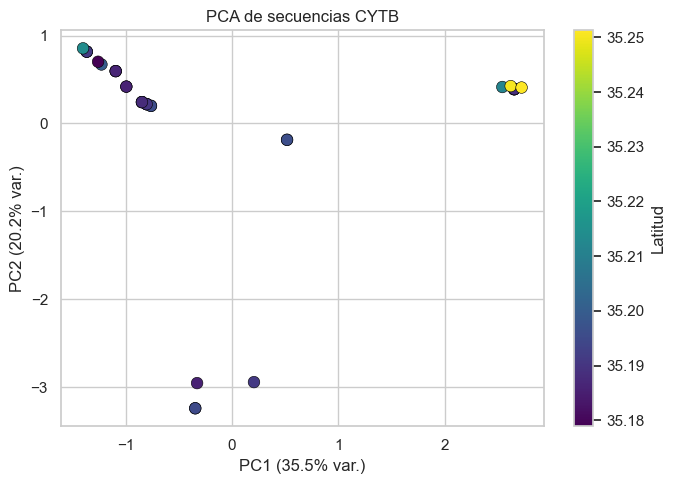

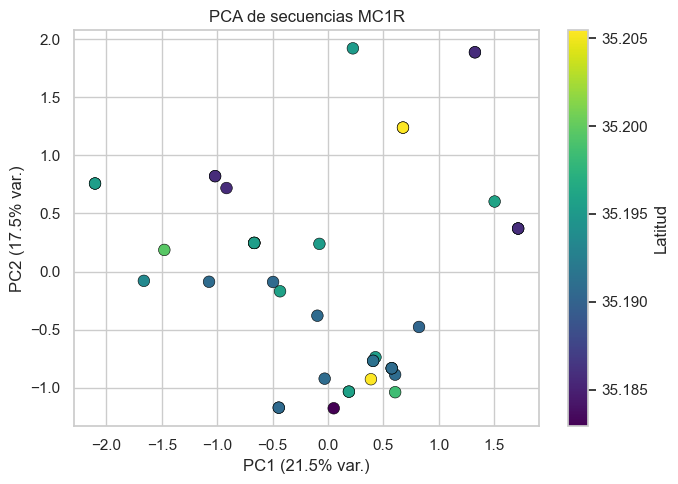

,marker,n,pc1_var,pc2_var
0,cytb,35,0.355208,0.201508
1,mc1r,42,0.215475,0.174580


In [4]:
pca_summaries = []

for marker, df in marker_data.items():
    X = one_hot_sequences(df["sequence"])
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    coords_pca = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(
        coords_pca[:, 0],
        coords_pca[:, 1],
        c=df["latitude"],
        cmap="viridis",
        s=70,
        edgecolor="black",
        linewidth=0.4,
    )
    ax.set_title(f"PCA de secuencias {marker.upper()}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)")
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label("Latitud")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / f"pca_{marker}.png", dpi=160)
    plt.show()

    pca_summaries.append({
        "marker": marker,
        "n": len(df),
        "pc1_var": pca.explained_variance_ratio_[0],
        "pc2_var": pca.explained_variance_ratio_[1],
    })

pca_summary = pd.DataFrame(pca_summaries)
display(pca_summary)

## Distancia geografica vs distancia genetica

Cada punto de las siguientes graficas representa un par de individuos. La pendiente se interpreta como el cambio esperado en distancia genetica por cada 100 km adicionales de separacion geografica.

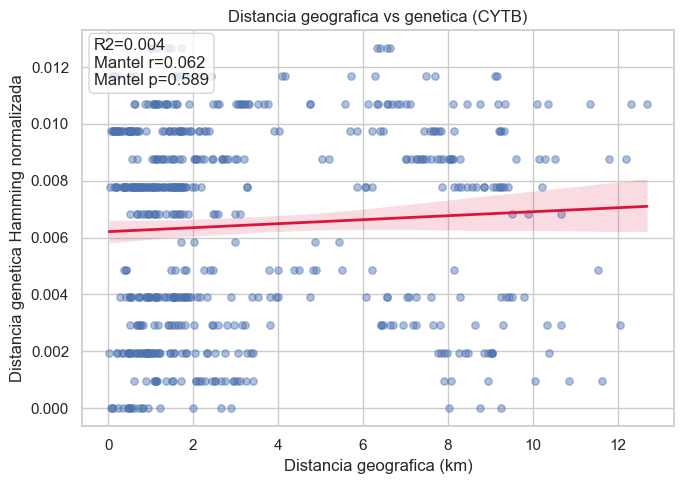

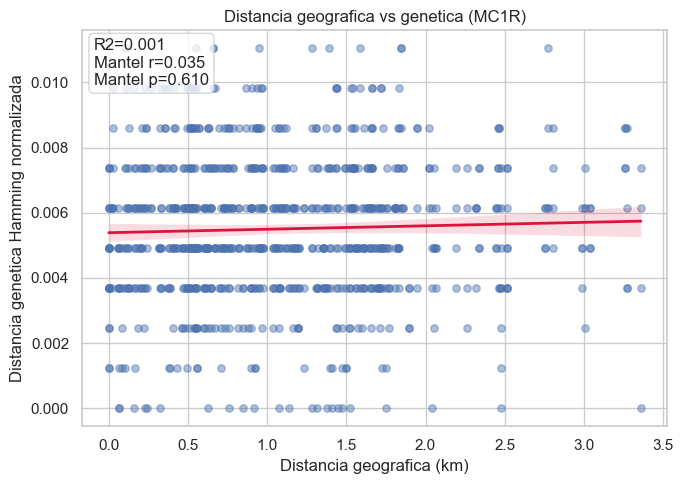

,marker,n_individuos,n_pares,pendiente_por_100km,intercepto,r2_ols,p_ols_pendiente,mantel_r,mantel_p,n,pc1_var,pc2_var
0,cytb,35,595,0.007012,0.006211,0.003899,0.128169,0.062440,0.589,35,0.355208,0.201508
1,mc1r,42,861,0.010558,0.005387,0.001242,0.301552,0.035249,0.610,42,0.215475,0.174580


In [5]:
regression_summaries = []

for marker, df in marker_data.items():
    genetic_D = hamming_distance_matrix(df["sequence"])
    geo_D = haversine_matrix(df["latitude"], df["longitude"])

    pairs = pd.DataFrame({
        "distancia_geografica_km": upper_triangle_values(geo_D),
        "distancia_genetica": upper_triangle_values(genetic_D),
    })
    pairs["distancia_geografica_100km"] = pairs["distancia_geografica_km"] / 100

    X = sm.add_constant(pairs["distancia_geografica_100km"])
    model = sm.OLS(pairs["distancia_genetica"], X).fit()
    mantel_r, mantel_p = mantel_test(geo_D, genetic_D, permutations=999, seed=RANDOM_SEED)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.regplot(
        data=pairs,
        x="distancia_geografica_km",
        y="distancia_genetica",
        scatter_kws={"alpha": 0.45, "s": 28},
        line_kws={"color": "crimson", "linewidth": 2},
        ax=ax,
    )
    ax.set_title(f"Distancia geografica vs genetica ({marker.upper()})")
    ax.set_xlabel("Distancia geografica (km)")
    ax.set_ylabel("Distancia genetica Hamming normalizada")
    ax.text(
        0.02,
        0.98,
        f"R2={model.rsquared:.3f}\nMantel r={mantel_r:.3f}\nMantel p={mantel_p:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.8, "edgecolor": "#cccccc"},
    )
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / f"distancia_geografica_genetica_{marker}.png", dpi=160)
    plt.show()

    regression_summaries.append({
        "marker": marker,
        "n_individuos": len(df),
        "n_pares": len(pairs),
        "pendiente_por_100km": model.params["distancia_geografica_100km"],
        "intercepto": model.params["const"],
        "r2_ols": model.rsquared,
        "p_ols_pendiente": model.pvalues["distancia_geografica_100km"],
        "mantel_r": mantel_r,
        "mantel_p": mantel_p,
    })

regression_summary = pd.DataFrame(regression_summaries)
summary = regression_summary.merge(pca_summary, on=["marker"], how="left")
summary_path = RESULTS_DIR / "resumen_pca_distancias.csv"
summary.to_csv(summary_path, index=False)
display(summary)

## Resultados principales

- `cytb`: pendiente de 0.0070 por cada 100 km, R2 = 0.0039, p OLS = 0.128; Mantel r = 0.062, p = 0.589. PC1 y PC2 explican aproximadamente 35.5% y 20.2% de la variacion.
- `mc1r`: pendiente de 0.0106 por cada 100 km, R2 = 0.0012, p OLS = 0.302; Mantel r = 0.035, p = 0.610. PC1 y PC2 explican aproximadamente 21.5% y 17.5% de la variacion.

En ambos marcadores la pendiente es positiva, pero la relacion distancia geografica-distancia genetica es muy debil y no significativa en este analisis exploratorio. Esto sugiere que, con estos datos y usando distancia directa, no hay evidencia clara de aislamiento por distancia.

## Distancia morfologica vs distancia geografica

Esta parte queda como limitacion del analisis. El archivo `data/processed/morfometricos.csv` contiene medidas morfometricas y una columna `fuente`, pero no incluye coordenadas reproducibles por individuo ni por sitio. Sin esas coordenadas no es posible calcular una matriz de distancia geografica comparable con una matriz de distancia morfologica sin introducir informacion externa no documentada.

Para hacer esta comparacion despues, bastaria agregar una tabla con coordenadas verificadas para cada individuo o, al menos, para cada sitio (`Cerro_Bachoco_2019`, `Cerro_Johnson_2019`, `Playa_Miramar_2019`) y definir si las distancias se compararan a nivel individuo-individuo o sitio-sitio.

## Lectura para presentacion

- El PCA muestra la variacion genetica principal por marcador y permite observar si existe un gradiente geografico visual asociado a la latitud.
- La regresion distancia geografica-distancia genetica cuantifica si la divergencia genetica aumenta con la separacion espacial.
- La prueba tipo Mantel se reporta como apoyo exploratorio porque trabaja directamente con matrices de distancia.
- El resultado debe interpretarse como evidencia exploratoria: se usa distancia directa y no se modelan barreras, habitat, terreno ni historia poblacional.